# 10 — Support Vector Machines

**Prerequisite:** notebook 09. **Theory used:** §1.2, §6.2.

An SVM finds the **widest road** that separates the classes — the maximum‑
margin hyperplane. That single geometric idea generalises remarkably well,
and the **kernel trick** turns it into one of the most powerful classifiers
for small‑to‑medium, high‑dimensional data. It also shares kNN's and the
MLP's fatal flaw: it only works on **scaled** features (§1.2).

## What you'll be able to do after this notebook

1. Explain what a **margin** is and why maximising it generalises.
2. Distinguish **hard** vs **soft** margin and what `C` controls.
3. Explain the **kernel trick** — and visualise linear / poly / RBF boundaries.
4. Tune `C` and `gamma` properly (with CV, not guesswork).
5. Recognise when SVM is the wrong choice (large data, NEED for
 interpretability) and when it shines.
6. See the failure case: **unscaled features silently destroying the margin**.

## The process

```mermaid
flowchart TD
 SC["Scale the data<br/> non‑negotiable for SVM — §1.2"] --> LIN
 LIN["Try a linear SVM first<br/><small>cheap baseline</small>"] --> RBF
 RBF["If not separable, try RBF kernel"] --> GS
 GS["Grid‑search C and gamma via CV<br/><small>log scale</small>"] --> CMP
 CMP["Compare to a forest / logreg<br/>is the SVM's edge worth its cost? — §5"]
```

## 1. The idea, in plain language

Given two classes, infinitely many lines can separate them. Which is best? The
SVM's answer: **the one that stays furthest from the nearest points of either
class** — i.e., the one with the widest empty "road" (margin) down the middle.

```
 ● ● ● ← class A
 ● ● ───────── ← decision boundary (max‑margin hyperplane)
 ╎╎╎╎╎╎╎╎╎ ← margin (the "road")
 ─────────
 ● ● ● ← class B
 ● ●
```

- The points sitting exactly on the margin edges are the **support vectors** —
 they're the only points that matter; moving any other point doesn't change
 the boundary. (Hence the name.)
- Maximising the margin = maximising confidence = better generalisation (a
 wide road is robust to noise).

**When classes overlap:** a perfect road is impossible, so the **soft margin**
lets some points cross the road (or sit on the wrong side) for a penalty. `C`
controls that penalty — more on this in §3.

## 2. Worked example A — visualising margins on synthetic 2D data

Two clean clusters in 2D — the perfect sandbox for *seeing* what SVM does.

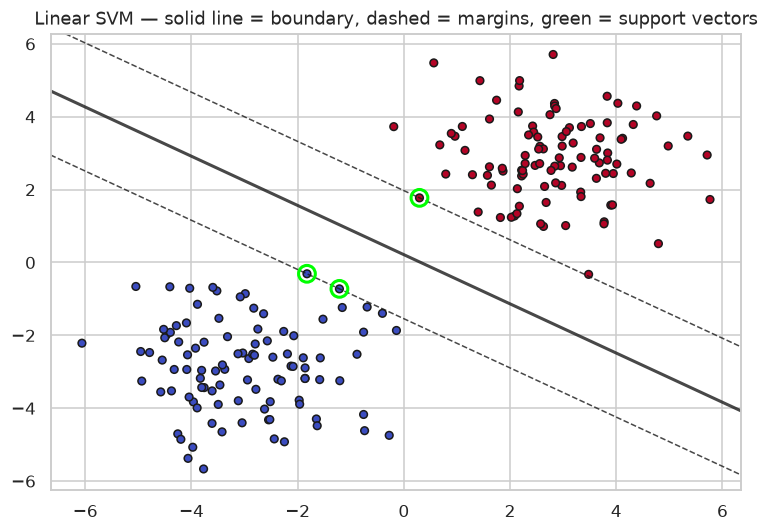

number of support vectors: 3 of 200 points


In [1]:
from setup import *
from sklearn.datasets import make_blobs, make_circles, make_moons

# Two well-separated blobs
X, y = make_blobs(n_samples=200, centers=[(-3, -3), (3, 3)],
 cluster_std=1.2, random_state=0)

def plot_svm(model, X, y, ax, title):
 # Plot the data, decision boundary, margins, and support vectors.
 ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=25, edgecolor="k", zorder=2)
 xlim = ax.get_xlim(); ylim = ax.get_ylim()
 xx, yy = np.meshgrid(np.linspace(*xlim, 30), np.linspace(*ylim, 30))
 grid = np.c_[xx.ravel(), yy.ravel()]
 # decision_function = signed distance to the hyperplane
 Z = model.decision_function(grid).reshape(xx.shape)
 ax.contour(xx, yy, Z, colors="k", levels=[-1, 0, 1],
 linestyles=["--", "-", "--"], linewidths=[1, 2, 1], alpha=0.8)
 # support vectors
 ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
 s=120, facecolors="none", edgecolors="lime", linewidths=2, zorder=3)
 ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_title(title)

# Linear SVM with the margin road visible
svm_lin = SVC(kernel="linear", C=1.0).fit(X, y)
fig, ax = plt.subplots(figsize=(7, 5))
plot_svm(svm_lin, X, y, ax, "Linear SVM — solid line = boundary, dashed = margins, green = support vectors")
plt.tight_layout(); plt.show()
print(f"number of support vectors: {len(svm_lin.support_vectors_)} of {len(X)} points")

**Reading the plot:**
- The **solid line** is the decision boundary (where `decision_function = 0`).
- The **two dashed lines** mark the margins (±1 in decision‑function units).
- **Green circles** are the support vectors — the points defining the road.
Everything else could be deleted and the boundary wouldn't move. That's why SVM
is memory‑efficient at prediction: only the support vectors are stored.

## 3. The `C` parameter — hard vs soft margin

`C` is the **regularisation dial** (§6.2), SVM‑flavoured:

- **Large C** → strict margin; points crossing it are heavily penalised →
 **narrow road, low bias, high variance** (overfit risk). Approaches the
 "hard margin" ideal.
- **Small C** → relaxed margin; crossings are tolerated → **wide road, higher
 bias, lower variance** (smoother, more robust).

There's no "right" C — you tune it with cross‑validation.

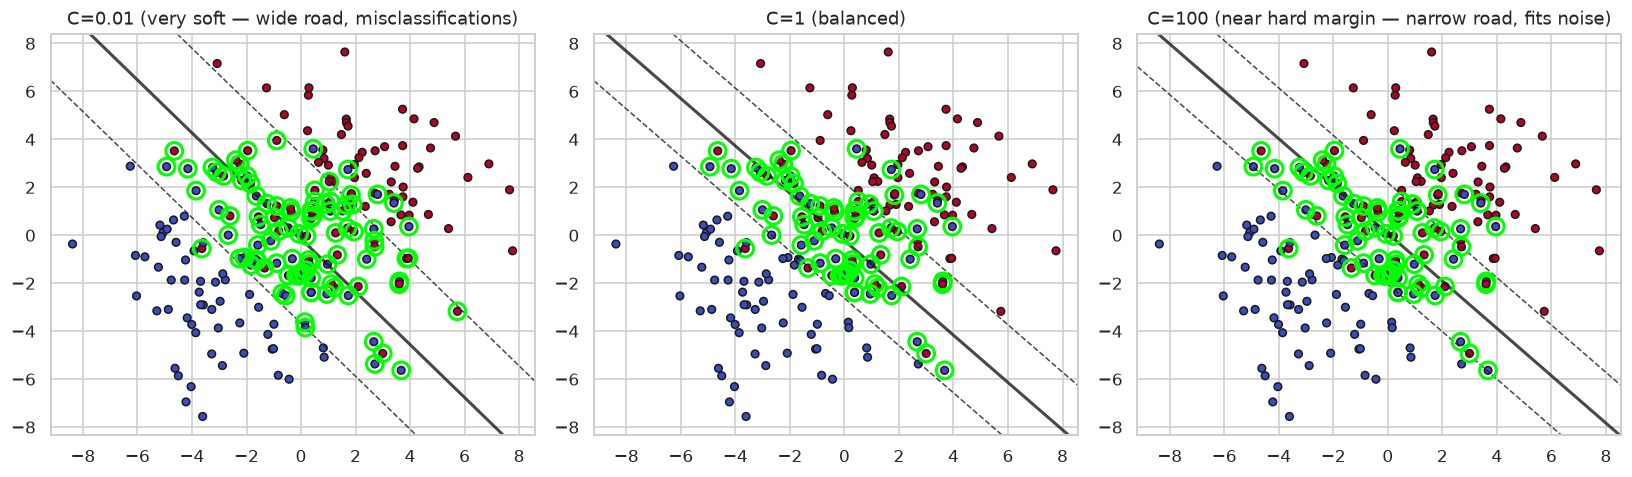

In [2]:
# Same blobs but noisier — points overlap. Watch the margin adapt to C.
Xn, yn = make_blobs(n_samples=200, centers=[(-2, -2), (2, 2)],
 cluster_std=2.5, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, C, title in zip(axes, [0.01, 1, 100],
 ["C=0.01 (very soft — wide road, misclassifications)",
 "C=1 (balanced)",
 "C=100 (near hard margin — narrow road, fits noise)"]):
 m = SVC(kernel="linear", C=C).fit(Xn, yn)
 plot_svm(m, Xn, yn, ax, title)
plt.tight_layout(); plt.show()

**The bias/variance story (§6.2) made visible:**
- **C=0.01:** wide road that ignores many misclassified points — high bias, low
 variance. Robust to noise but may underfit.
- **C=100:** narrow road contorting to classify every training point — low
 bias, high variance. Memorises noise.
- **C=1:** the Goldilocks zone, found via CV.

## 4. The kernel trick — separating the inseparable

When a straight line can't separate the classes, two options:

1. **Engineer features** by hand (e.g. add $x_1^2, x_2^2, x_1 x_2$) and hope the
 classes become linearly separable in the higher‑dimensional space.
2. **The kernel trick:** let SVM compute the *dot products* in that higher‑
 dimensional space *without ever visiting it explicitly*. The math lets us
 act as if we'd added those features, at no extra memory cost.

| Kernel | Hyperparams | Boundary shape | When |
|---|---|---|---|
| **linear** | `C` | straight line / hyperplane | linearly separable; very high‑dim (text) |
| **polynomial** | `C`, `degree`, `coef0` | curved polynomial | mild nonlinearity |
| **RBF (Gaussian)** | `C`, `gamma` | flexible, smooth | the default; most nonlinear problems |

Let's see them on the classic "concentric circles" dataset — *no straight line
separates these, but an RBF kernel does instantly*.

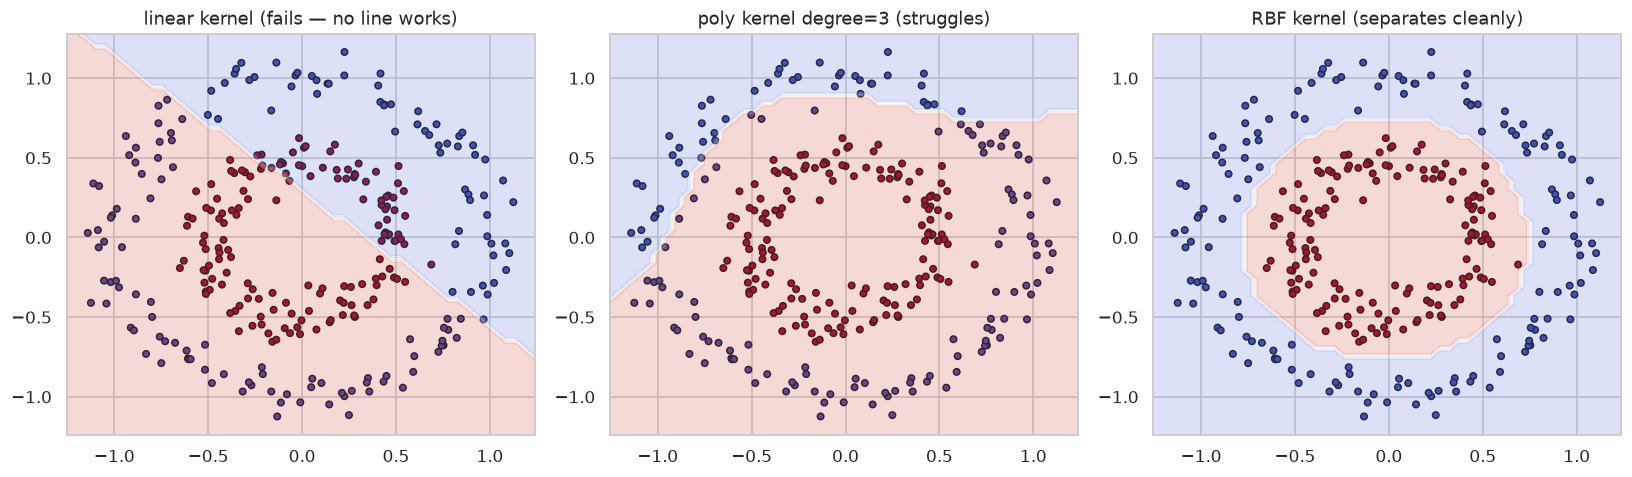

In [3]:
Xc, yc = make_circles(n_samples=300, noise=0.08, factor=0.5, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, kernel, title in zip(axes,
 ["linear", "poly", "rbf"],
 ["linear kernel (fails — no line works)",
 "poly kernel degree=3 (struggles)",
 "RBF kernel (separates cleanly)"]):
 m = SVC(kernel=kernel, C=1.0, degree=3, gamma="auto").fit(Xc, yc)
 axes_scatter_kw = dict(c=yc, cmap="coolwarm", s=18, edgecolor="k")
 ax.scatter(Xc[:,0], Xc[:,1], **axes_scatter_kw)
 xlim = ax.get_xlim(); ylim = ax.get_ylim()
 xx, yy = np.meshgrid(np.linspace(*xlim, 50), np.linspace(*ylim, 50))
 Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
 ax.set_title(title)
plt.tight_layout(); plt.show()

**The punchline:** the linear kernel's boundary is a hopeless straight cut
through concentric rings. The polynomial one tries to bend but struggles. The
**RBF kernel** wraps the boundary around the inner ring perfectly — *without
you ever manually engineering the polar coordinates*.

## 5. Tuning `C` and `gamma` — the two RBF knobs

For an RBF SVM, you grid‑search two parameters **on a log scale**:

- **`C`** — overall regularisation (same as before).
- **`gamma`** — how far each training point's influence reaches.
 - **Large gamma** → each point's influence is tight → boundary wiggles around
 individual points → **overfit**.
 - **Small gamma** → influence is broad → boundary is smooth → **underfit**.

**Rule of thumb:** always search `C ∈ {0.1, 1, 10, 100}` × `gamma ∈ {0.001,
0.01, 0.1, 1}` with CV. The two interact, so don't tune them independently.

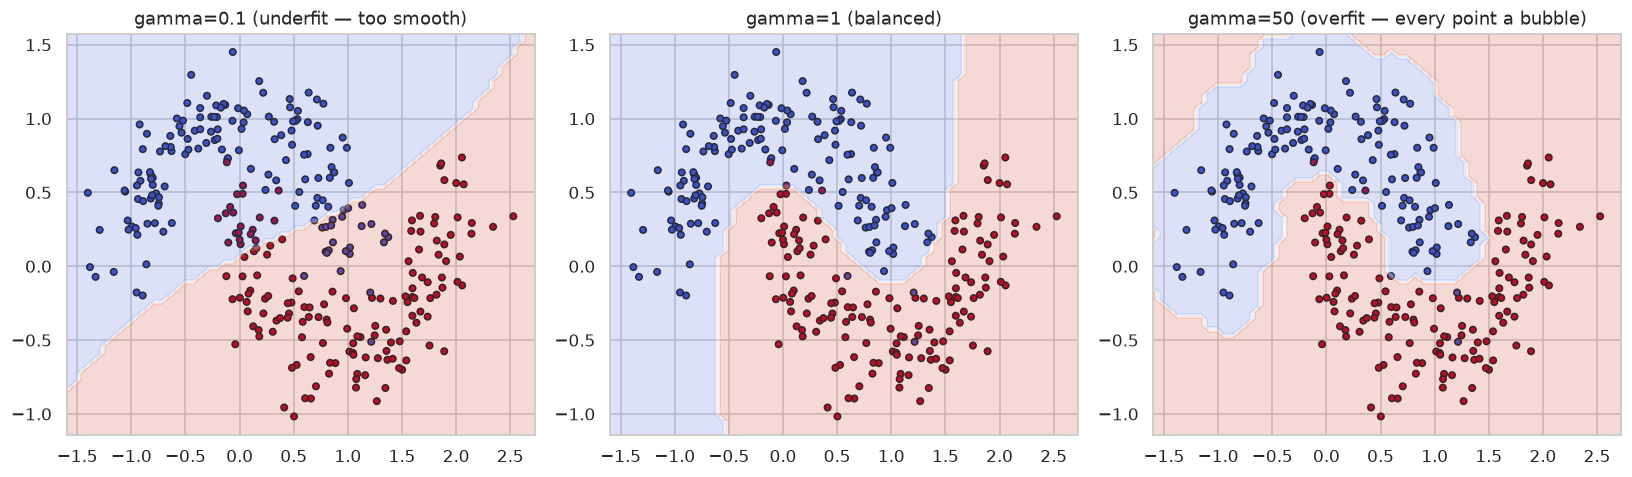

In [4]:
# Visualise gamma's effect on the noisy moons dataset.
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, gamma, title in zip(axes, [0.1, 1, 50],
 ["gamma=0.1 (underfit — too smooth)",
 "gamma=1 (balanced)",
 "gamma=50 (overfit — every point a bubble)"]):
 m = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(Xm, ym)
 ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap="coolwarm", s=18, edgecolor="k")
 xlim = ax.get_xlim(); ylim = ax.get_ylim()
 xx, yy = np.meshgrid(np.linspace(*xlim, 60), np.linspace(*ylim, 60))
 Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
 ax.set_title(title)
plt.tight_layout(); plt.show()

In [5]:
# Proper grid search on breast-cancer (a real, high-dim dataset where SVM shines).
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
Xb, yb = bc.data, bc.target

# roc_auc works via decision_function — no need for probability=True
# (which is deprecated in sklearn 1.9 anyway).
pipe = Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf"))])
param_grid = {
 "svm__C": [0.1, 1, 10, 100],
 "svm__gamma": [0.001, 0.01, 0.1, 1],
}
gs = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
gs.fit(Xb, yb)
results = (pd.DataFrame(gs.cv_results_)
 .sort_values("rank_test_score")
 [["param_svm__C", "param_svm__gamma", "mean_test_score", "std_test_score"]]
 .head(8))
results.round(3)

,param_svm__C,param_svm__gamma,mean_test_score,std_test_score
9,10.0,0.010,0.997,0.004
12,100.0,0.001,0.995,0.004
13,100.0,0.010,0.995,0.004
5,1.0,0.010,0.995,0.005
8,10.0,0.001,0.995,0.006
6,1.0,0.100,0.992,0.005
4,1.0,0.001,0.992,0.007
1,0.1,0.010,0.989,0.007


**Reading the grid:** the best configs cluster in a *band* across the C × gamma
table — neither extreme is good. The very high‑gamma cells overfit (score
collapses); the very low ones underfit. This is why you grid‑search both
together, never tune them one at a time.

## 6. Worked example B — CEO dataset (and SVM's honest limits)

The CEO data is small and mostly categorical — SVM is overkill, but the process
is instructive. We one‑hot + scale, then run the same grid search.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ceo = pd.read_csv("data/ceo_data.csv")
Xc = ceo.drop(columns=["Stock_Market"])
yc = (ceo["Stock_Market"] == "Yes").astype(int)

cat = Xc.select_dtypes(include=["object", "string"]).columns.tolist()
num = Xc.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("num", StandardScaler(), num),
 ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
pipe_ceo = Pipeline([("pre", pre), ("svm", SVC(kernel="rbf"))])
gs_ceo = GridSearchCV(pipe_ceo,
 {"svm__C": [0.1, 1, 10], "svm__gamma": [0.01, 0.1, "scale"]},
 cv=5, scoring="roc_auc")
gs_ceo.fit(Xc, yc)
print(f"best CV AUC on CEO: {gs_ceo.best_score_:.3f}")
print(f"baseline (guess Yes): {yc.mean():.3f}")
print(f"best params: {gs_ceo.best_params_}")

best CV AUC on CEO: 0.534
baseline (guess Yes): 0.700
best params: {'svm__C': 10, 'svm__gamma': 'scale'}


On 60 rows SVM, like the MLP and kNN before it, barely edges the baseline — the
data is the bottleneck, not the model. Notebooks 11–13 cover what to do when
no classifier helps (dimensionality reduction, clustering, model comparison).

## 7. Failure case — unscaled features destroy the margin

SVM measures distance to compute the margin and (for RBF) the kernel. Any
feature on a large scale **dominates** both, so the "maximum margin" gets
optimised along one axis only — the SVM is making decisions on garbage. This is
the same kNN/MLP story (§1.2), but it hides better because SVM still
*runs* without warnings.

In [7]:
# Build data where 1 informative feature (scale 1) + 1 noise feature (scale 1000).
rng = np.random.default_rng(0)
n = 400
signal = rng.normal(0, 1, n)
noise = rng.normal(0, 1, n) * 1000
y_bin = (signal + rng.normal(0, 0.5, n) > 0).astype(int)
X_bad = np.column_stack([signal, noise])
X_tr, X_te, y_tr, y_te = train_test_split(X_bad, y_bin, test_size=0.3, random_state=0)

unscaled = SVC(kernel="rbf", C=1, gamma="auto").fit(X_tr, y_tr)
scaled = Pipeline([("sc", StandardScaler()),
 ("svm", SVC(kernel="rbf", C=1, gamma="auto"))]).fit(X_tr, y_tr)
print(f"UNScaled SVM accuracy: {unscaled.score(X_te, y_te):.3f} (chasing the noise axis)")
print(f"scaled SVM accuracy: {scaled.score(X_te, y_te):.3f} (using the signal axis)")

UNScaled SVM accuracy: 0.533 (chasing the noise axis)
scaled SVM accuracy: 0.808 (using the signal axis)


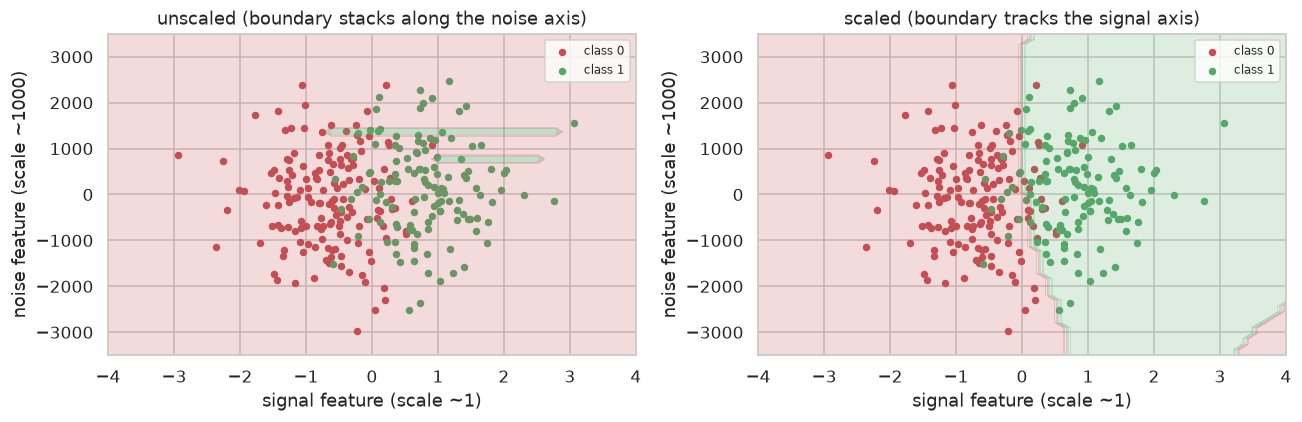

In [8]:
# Same visual as the kNN notebook: boundary in original coords.
from matplotlib.colors import ListedColormap
cmap_pts = ListedColormap(["#c44e52", "#55a868"])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, model, title in zip(ax, [unscaled, scaled],
 ["unscaled (boundary stacks along the noise axis)",
 "scaled (boundary tracks the signal axis)"]):
 a.scatter(X_tr[y_tr==0,0], X_tr[y_tr==0,1], c="#c44e52", s=15, label="class 0")
 a.scatter(X_tr[y_tr==1,0], X_tr[y_tr==1,1], c="#55a868", s=15, label="class 1")
 xlim = (-4, 4); ylim = (-3500, 3500)
 xx, yy = np.meshgrid(np.linspace(*xlim, 60), np.linspace(*ylim, 60))
 grid = np.c_[xx.ravel(), yy.ravel()]
 pred = model.predict(grid).reshape(xx.shape)
 a.contourf(xx, yy, pred, alpha=0.2, cmap=cmap_pts)
 a.set_xlim(xlim); a.set_ylim(ylim)
 a.set_xlabel("signal feature (scale ~1)"); a.set_ylabel("noise feature (scale ~1000)")
 a.set_title(title); a.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

**The picture:** the unscaled SVM's boundary is a stack of horizontal bands
driven entirely by the noise feature. Same model, same data, same
hyperparameters — *scaling is the only difference*. Always scale, inside a
`Pipeline`.

## 8. When to use SVM (and when not to)

**SVM shines when:**
- **Medium‑sized, high‑dimensional** tabular data (hundreds–thousands of
 features, ≤ ~50k rows). Text with TF‑IDF is classic SVM territory.
- You need a **single, principled** classifier with a clear tuning procedure
 (C × gamma grid).
- Memory matters at serving time — only the support vectors are stored.

**SVM struggles when:**
- **Very large data** (`n > 100k`) — training cost is roughly $O(n^2)$–$O(n^3)$;
 random forests / boosting / logistic regression scale far better.
- You need **probabilities out of the box** — wrap the SVM in
 `CalibratedClassifierCV(SVC(...), ensemble=False)` (sklearn ≥1.5); it's an
 extra cross‑validation (Platt scaling), so only do it when you truly need
 calibrated probabilities. For ranking/scoring (AUC), `decision_function`
 works directly and is free.
- **Interpretability** is required — the kernel makes the model a black box;
 for direction‑of‑effect, use logistic regression or a tree.
- You have mostly **categorical** features — one‑hot them and a linear model
 usually wins anyway.

> For most modern tabular problems, **gradient boosting (notebook 08)** is the
> strong default; SVM is a tool to reach for specifically when its strengths
> match your data shape.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Forgetting to scale (§7).** The #1 SVM bug, and it gives *no warning*.
 Always `StandardScaler` inside the pipeline.
2. **Tuning C and gamma independently.** They interact — always grid‑search
 them together, on a log scale.
3. **Defaulting to RBF without trying linear.** On very high‑dimensional data
 (text, genes) a **linear** SVM is often as good and 100× faster. Try it
 first.
4. **Wrapping in `CalibratedClassifierCV` by reflex.** It's an extra CV inside
 training — slow. Only calibrate if you actually need probabilities; for
 ranking/scoring, `decision_function` is free.
5. **SVM on huge data.** $O(n^2{+})$ training cost. Past ~50–100k rows, switch
 to a forest or boosting.
6. **Interpreting support vectors as "important features".** They're important
 *points*, not features — SVM has no native feature importance. Use
 permutation importance (notebook 08) if you need it.
7. **Treating the margin width as a confidence calibration.** A wider margin
 ≠ well‑calibrated probabilities. For real calibration, see notebook 05's
 note on calibration curves.

## Exercises

1. **Margin reading.** In §2, delete one non‑support‑vector point from the data
 and refit. Does the boundary move? Now delete a support vector — does it?
 Why?
2. **Kernel choice.** On the **moons** dataset, fit linear, poly(degree=3), and
 rbf SVMs with `C=1`. Report CV accuracy. Which wins, and why does linear
 struggle where RBF doesn't?
3. **C and gamma, yourself.** On breast‑cancer, instead of the grid, try
 `C=1e6, gamma="auto"` (near hard margin). What happens to CV AUC? Relate to
 the bias/variance trade‑off (§6.2).
4. **Scaling, quantified.** In §7, swap `StandardScaler` for no scaling but
 *manually* divide the noise feature by 1000. Does the SVM recover? Why is
 this equivalent to scaling?
5. **SVM vs forest.** On breast‑cancer, compare the best‑tuned RBF SVM to a
 random forest (notebook 08). Report CV AUC ± std. Is the SVM's edge (if any)
 real, or within noise (§5)?

<details><summary>Answers (click to expand)</summary>

```python
# 1: Deleting a non-support-vector point -> boundary unchanged (that's the
# definition of a support vector: only they matter). Deleting a support
# vector -> boundary moves (it was propping up the margin).

# 2
from sklearn.model_selection import cross_val_score
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=0)
for k in ["linear", "poly", "rbf"]:
 p = Pipeline([("sc",StandardScaler()),("svm",SVC(kernel=k, C=1, degree=3, gamma="auto"))])
 print(k, cross_val_score(p, Xm, ym, cv=5).mean())
# RBF wins; linear struggles because moons aren't linearly separable; poly is
# in between.

# 3: C=1e6 forces a near-hard margin -> the SVM tries to classify every point,
# overfits, CV AUC drops. Classic high-variance failure.

# 4: Manually dividing the noise feature by 1000 puts it on the same scale as
# the signal feature -> SVM recovers fully. That's exactly what
# StandardScaler does (in a more principled, data-driven way). It's proof
# that "scaling" just means "put features on comparable magnitudes".

# 5: On breast-cancer the best RBF SVM and a well-tuned forest are usually
# within ~1% AUC of each other -> the difference is within CV noise. Pick
# the simpler/faster one unless you have a specific reason.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (scaling & variance), §6.2 (C and gamma as the bias/variance dials).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 14 —
 <https://bradleyboehmke.github.io/HOML/svm.html>.
- scikit‑learn — *Support Vector Machines* user guide:
 <https://scikit-learn.org/stable/modules/svm.html>; *RBF SVM parameters*
 example: <https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html>.
- Cortes & Vapnik (1995), *Support‑Vector Networks*, Machine Learning — the
 original soft‑margin SVM paper.